# Xente Credit Risk — Exploratory Data Analysis

Exploratory analysis of the Xente transaction dataset (`data/raw/data.csv`).

**Goal:** understand the structure, distributions, data-quality issues, and relationships in the data to guide feature engineering and the design of the RFM-based proxy target.

> This notebook is for **exploration only** — production logic lives in `src/`.

**Sections**
1. Data overview (shape, dtypes)
2. Summary statistics
3. Distribution of numerical features
4. Distribution of categorical features
5. Correlation analysis
6. Missing values
7. Outlier detection
8. Key insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/data.csv", parse_dates=["TransactionStartTime"])
df.shape

(95662, 16)

## 1. Overview of the Data

Number of rows, columns, data types, and a first look at the records.

In [2]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 95,662  |  Columns: 16


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  str                
 1   BatchId               95662 non-null  str                
 2   AccountId             95662 non-null  str                
 3   SubscriptionId        95662 non-null  str                
 4   CustomerId            95662 non-null  str                
 5   CurrencyCode          95662 non-null  str                
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  str                
 8   ProductId             95662 non-null  str                
 9   ProductCategory       95662 non-null  str                
 10  ChannelId             95662 non-null  str                
 11  Amount                95662 non-null  float64            
 12  Value          

In [4]:
# Cardinality of each column — identifies IDs, constants, and true categoricals
card = df.nunique().sort_values()
card.to_frame("unique_values")

,unique_values
CountryCode,1
CurrencyCode,1
FraudResult,2
ChannelId,4
PricingStrategy,4
ProviderId,6
ProductCategory,9
ProductId,23
Value,1517
Amount,1676


**Observations**
- 95,662 transactions across 16 columns.
- `CurrencyCode` (UGX) and `CountryCode` (256, Uganda) are **constant** — zero predictive value, candidates to drop.
- High-cardinality identifiers: `TransactionId`, `BatchId`, `SubscriptionId`, plus `CustomerId` (~3,742) and `AccountId` (~3,633). These are keys for aggregation, not direct model features.
- True low-cardinality categoricals: `ProviderId` (6), `ProductId` (23), `ProductCategory` (9), `ChannelId` (4), `PricingStrategy` (4).
- Time span runs ~3 months (Nov 2018 – Feb 2019).

## 2. Summary Statistics

Central tendency, dispersion, and shape for the numerical fields.

In [5]:
df[["Amount", "Value", "PricingStrategy", "FraudResult"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


In [6]:
# Skewness of the monetary fields
for col in ["Amount", "Value"]:
    print(f"{col:8s} skew = {df[col].skew():10.2f}   min = {df[col].min():>12,.0f}   max = {df[col].max():>12,.0f}")

Amount   skew =      51.10   min =   -1,000,000   max =    9,880,000
Value    skew =      51.29   min =            2   max =    9,880,000


In [7]:
# Class balance of the only existing label
fraud = df["FraudResult"].value_counts()
fraud_pct = df["FraudResult"].value_counts(normalize=True) * 100
pd.DataFrame({"count": fraud, "percent": fraud_pct.round(3)})

,count,percent
FraudResult,,
0,95469,99.798
1,193,0.202


**Observations**
- `Amount` ranges from **-1,000,000 to 9,880,000** with a mean of ~6,718 but a median of only 1,000 → extreme right skew driven by a few very large transactions.
- Negative `Amount` values represent credits to the customer; `Value` is the absolute amount, so the two carry overlapping information plus a sign.
- `FraudResult` is **severely imbalanced**: only ~0.2% of transactions are fraud. Any classification work here must account for imbalance (resampling, class weights, PR-AUC over plain accuracy).

## 3. Distribution of Numerical Features

Visualize distributions to spot skewness and outliers. Because the raw scale is dominated by extremes, we also view a log-transformed `Value`.

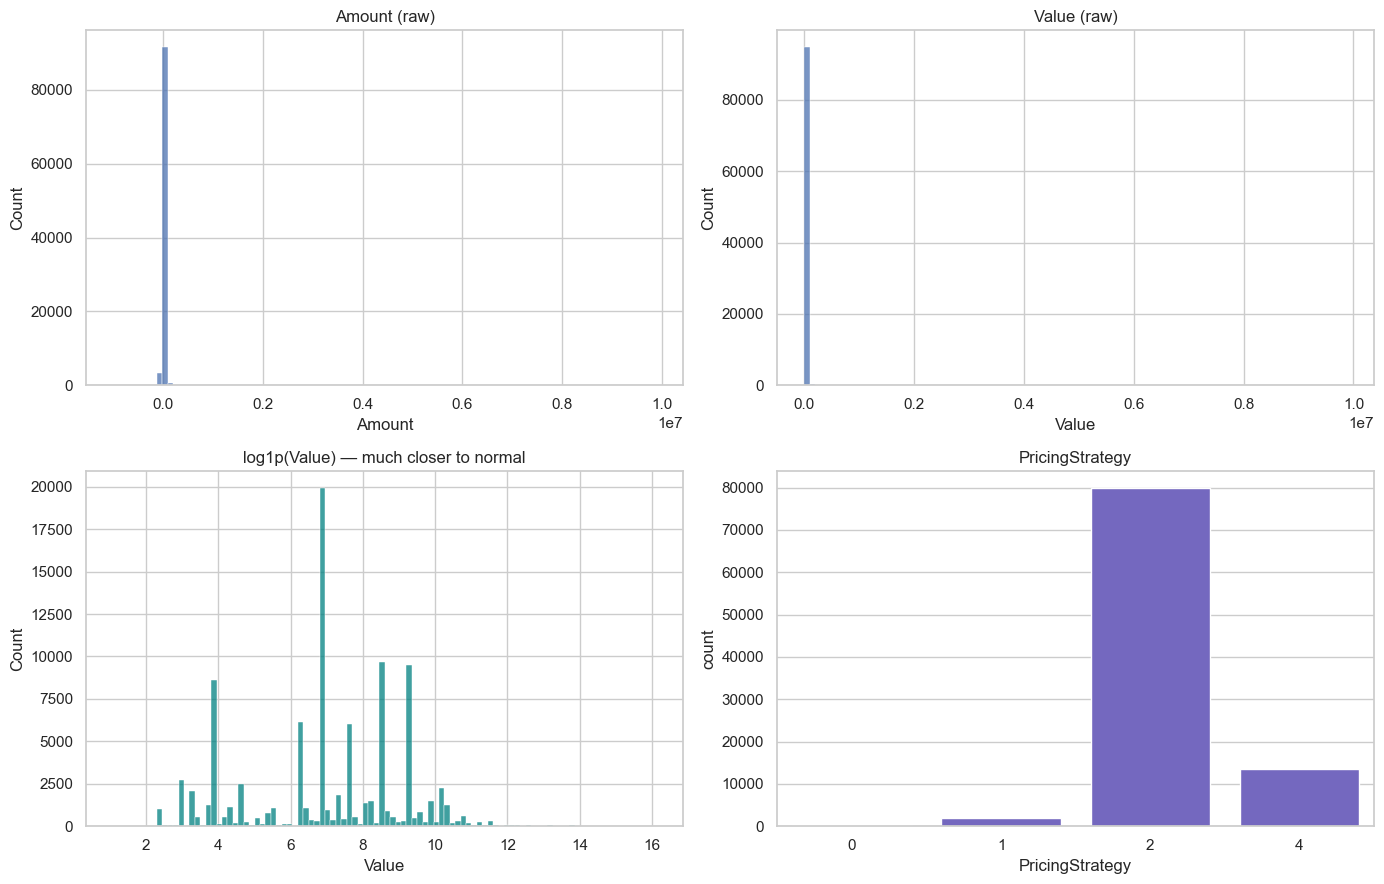

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df["Amount"], bins=100, ax=axes[0, 0])
axes[0, 0].set_title("Amount (raw)")

sns.histplot(df["Value"], bins=100, ax=axes[0, 1])
axes[0, 1].set_title("Value (raw)")

sns.histplot(np.log1p(df["Value"]), bins=100, ax=axes[1, 0], color="teal")
axes[1, 0].set_title("log1p(Value) — much closer to normal")

sns.countplot(x="PricingStrategy", data=df, ax=axes[1, 1], color="slateblue")
axes[1, 1].set_title("PricingStrategy")

plt.tight_layout()
plt.show()

**Observations**
- Raw `Amount`/`Value` are almost unreadable due to extreme skew — nearly all mass sits near zero with a long thin tail.
- A **log transform** on `Value` produces a far more usable, roughly bell-shaped distribution → strong signal that monetary features should be log-scaled before modeling.
- `PricingStrategy` is dominated by category `2` (~83%).

## 4. Distribution of Categorical Features

Frequency and variability of the categorical fields.

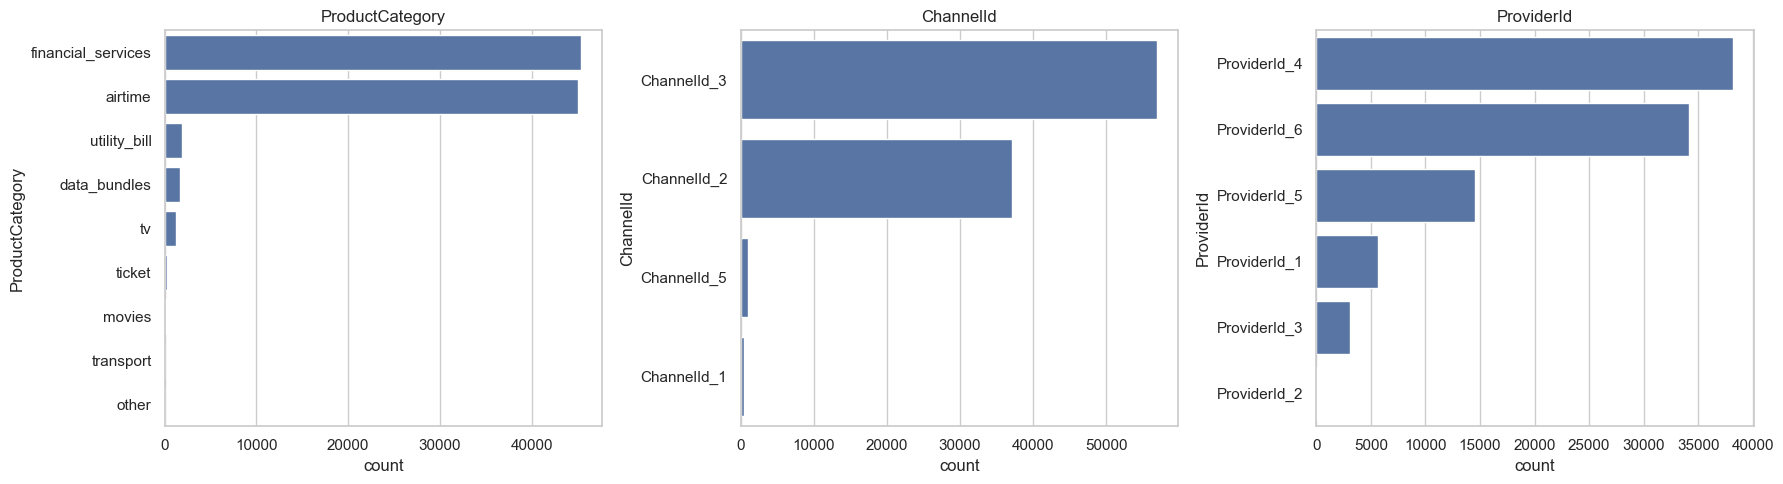

In [9]:
cat_cols = ["ProductCategory", "ChannelId", "ProviderId"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [10]:
for col in ["ProductCategory", "ChannelId", "ProviderId", "PricingStrategy"]:
    print(f"=== {col} ===")
    print((df[col].value_counts(normalize=True) * 100).round(2).to_string())
    print()

=== ProductCategory ===
ProductCategory
financial_services    47.46
airtime               47.07
utility_bill           2.01
data_bundles           1.69
tv                     1.34
ticket                 0.23
movies                 0.18
transport              0.03
other                  0.00

=== ChannelId ===
ChannelId
ChannelId_3    59.52
ChannelId_2    38.83
ChannelId_5     1.10
ChannelId_1     0.56

=== ProviderId ===
ProviderId
ProviderId_4    39.92
ProviderId_6    35.74
ProviderId_5    15.20
ProviderId_1     5.90
ProviderId_3     3.22
ProviderId_2     0.02

=== PricingStrategy ===
PricingStrategy
2    83.47
4    14.18
1     1.95
0     0.40



**Observations**
- `ProductCategory` is heavily concentrated: **`financial_services` (~47%) and `airtime` (~47%)** together account for ~95% of all transactions; the remaining 7 categories are rare.
- `ChannelId_3` and `ChannelId_2` dominate; `ChannelId_1` and `ChannelId_5` are minor.
- `ProviderId_4` and `ProviderId_6` handle the bulk of volume; `ProviderId_2` is negligible (18 rows).
- Rare categories may need grouping into an "other" bucket to stabilize encodings.

## 5. Correlation Analysis

Relationships among numerical features (and the fraud label).

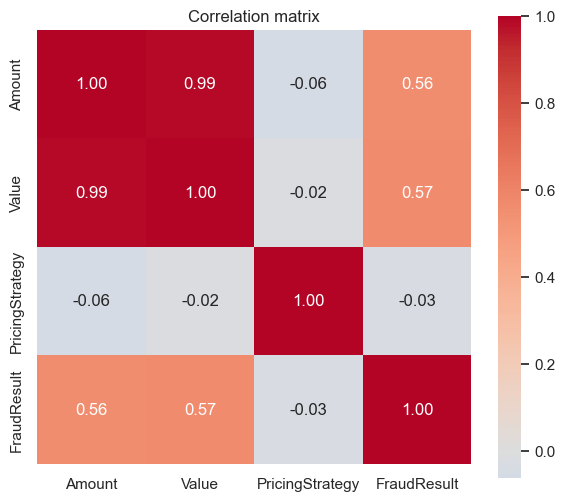

In [11]:
num_cols = ["Amount", "Value", "PricingStrategy", "FraudResult"]
corr = df[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix")
plt.show()

**Observations**
- `Amount` and `Value` are **almost perfectly correlated (~0.99)** — they are redundant. We should keep `Value` (magnitude) and derive a separate sign/direction feature from `Amount` rather than feed both.
- `Amount`/`Value` show a moderate positive correlation with `FraudResult` (~0.56) → larger transactions are more likely to be flagged as fraud.
- `PricingStrategy` is essentially uncorrelated with the other numerics.

## 6. Identifying Missing Values

Determine missingness to decide on imputation.

In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "percent": missing_pct})

,missing,percent
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


**Observations**
- The dataset has **no missing values** in any column — no imputation is required for the raw fields.
- Note: missingness can still appear later, e.g. when aggregating to customer level (customers with a single transaction yield no inter-transaction gap).

## 7. Outlier Detection

Box plots to surface extreme values in the monetary fields.

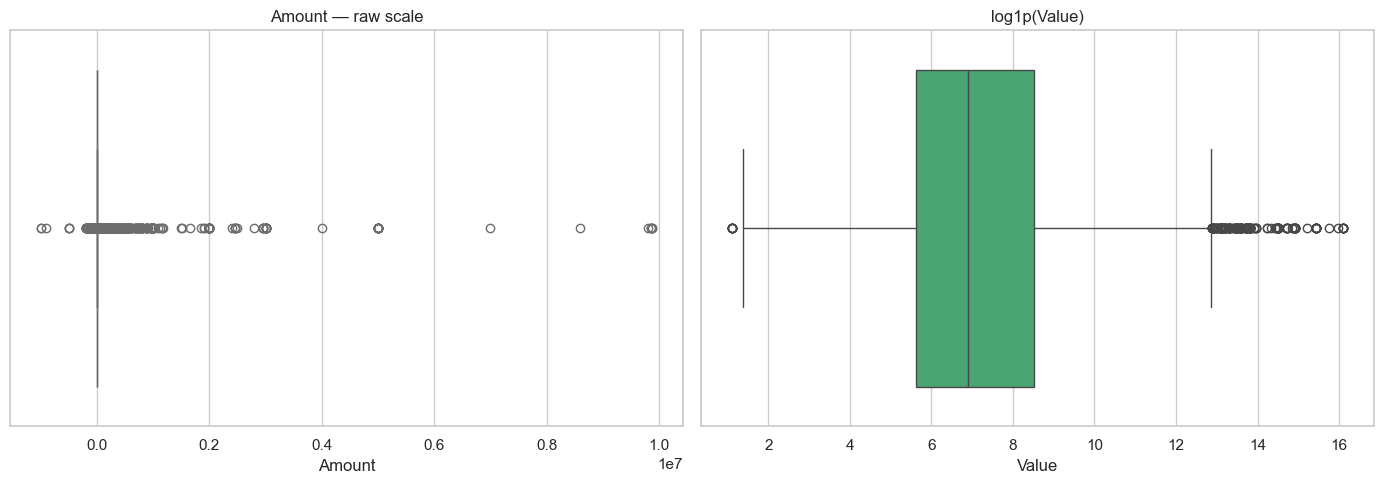

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["Amount"], ax=axes[0], color="salmon")
axes[0].set_title("Amount — raw scale")
sns.boxplot(x=np.log1p(df["Value"]), ax=axes[1], color="mediumseagreen")
axes[1].set_title("log1p(Value)")
plt.tight_layout()
plt.show()

In [14]:
# Quantify outliers with the IQR rule on Value
q1, q3 = df["Value"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_out = (df["Value"] > upper).sum()
print(f"IQR upper fence for Value: {upper:,.0f}")
print(f"Outliers above fence: {n_out:,} ({n_out / len(df) * 100:.2f}% of rows)")
print(f"Negative Amount (credits): {(df['Amount'] < 0).sum():,} ({(df['Amount'] < 0).mean() * 100:.1f}%)")

IQR upper fence for Value: 12,088
Outliers above fence: 9,021 (9.43% of rows)
Negative Amount (credits): 38,189 (39.9%)


**Observations**
- The monetary fields contain a large number of high-side outliers on the raw scale; the log transform compresses them into a far more symmetric range.
- ~40% of transactions have a **negative `Amount`** (credits/refunds) — direction is meaningful and should become its own feature.
- Outliers are unlikely to be data errors (the platform genuinely processes large transactions), so winsorizing/log-scaling is preferable to dropping them.

## 8. Key Insights (Summary)

The five most important takeaways guiding feature engineering and the proxy-target design:

1. **Drop constant / redundant columns.** `CurrencyCode` and `CountryCode` are single-valued (UGX, Uganda) and carry no signal. `Amount` and `Value` are ~0.99 correlated — keep `Value` as magnitude and derive a separate **sign/direction** feature from `Amount` (≈40% of rows are credits).

2. **Monetary features are extremely right-skewed and must be transformed.** `Amount`/`Value` span -1M to ~9.9M with mean ≫ median. A `log1p` transform yields a near-normal distribution, so log-scaling (plus winsorizing) is essential before modeling.

3. **The data is transaction-level and must be aggregated to the customer.** With ~3,742 customers across 95,662 transactions, credit risk is a *customer* property. The proxy target should be built from per-customer **RFM (Recency, Frequency, Monetary)** aggregates, not raw rows.

4. **Severe class imbalance.** The existing `FraudResult` label is only ~0.2% positive. This is a warning for the (different) proxy task too: evaluation must favor PR-AUC / recall over accuracy, and we should expect to handle imbalance explicitly.

5. **Categoricals are highly concentrated.** `financial_services` + `airtime` make up ~95% of transactions, and a few providers/channels dominate. Rare categories (e.g. `ProviderId_2`, `transport`) should be grouped to keep encodings stable; transaction size correlates with fraud, hinting that amount-based behavioral features will be informative.